In [1]:
import os
import io
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from compressai.zoo import cheng2020_anchor, cheng2020_attn, mbt2018_mean
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torchvision.transforms import functional as F
from typing import List, Dict, Optional

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu') #change to cuda if needed
print(f"Using device: {device}")

Using device: mps


In [3]:
def load_kodak(path='data/kodak/', size=None):
    """Load Kodak images as torch tensors (1, C, H, W) in [0,1]."""
    images = []
    for fname in sorted(os.listdir(path)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = Image.open(os.path.join(path, fname)).convert('RGB')
            if size is not None:
                img = img.resize(size, Image.BICUBIC)
            img = transforms.ToTensor()(img).unsqueeze(0)  # 1,C,H,W
            images.append(img)
    print(f"Loaded {len(images)} Kodak images.")
    return images

In [4]:
def gaussian_filter_defense(img: torch.Tensor, kernel_size: int = 5, sigma: float = 1.0) -> torch.Tensor:
    return F.gaussian_blur(img, kernel_size=[kernel_size, kernel_size], sigma=[sigma, sigma])

def median_filter_defense(img: torch.Tensor, kernel_size: int = 5) -> torch.Tensor:
    to_pil = transforms.ToPILImage()
    img_pil = to_pil(img.squeeze(0).cpu())
    img_pil = img_pil.filter(ImageFilter.MedianFilter(size=kernel_size))
    to_tensor = transforms.ToTensor()
    return to_tensor(img_pil).unsqueeze(0).to(img.device)

def jpeg_compress_defense(img: torch.Tensor, quality: int = 75) -> torch.Tensor:
    img_pil = transforms.ToPILImage()(img.squeeze(0).cpu())
    buffer = io.BytesIO()
    img_pil.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    img_jpeg = Image.open(buffer)
    return transforms.ToTensor()(img_jpeg).unsqueeze(0).to(img.device)

def bit_depth_reduction_defense(img: torch.Tensor, bits: int = 4) -> torch.Tensor:
    levels = 2**bits
    img_q = torch.round(img * (levels - 1)) / (levels - 1)
    return img_q

def sharp_pixel_defense(img: torch.Tensor, tau: float = 0.05, blur_sigma: float = 1.0) -> torch.Tensor:
    """
    Unsharp mask defense: sharpened = original + tau * (original - blurred)
    """
    kernel_size = int(2 * round(3 * blur_sigma) + 1)  # e.g., 7 for sigma=1.0
    blurred = F.gaussian_blur(img, kernel_size=[kernel_size, kernel_size], sigma=[blur_sigma, blur_sigma])
    sharpened = img + tau * (img - blurred)
    return torch.clamp(sharpened, 0, 1)

In [5]:
'''def psnr(img1, img2, max_val=1.0):
    mse = torch.mean((img1 - img2) ** 2).item()
    if mse < 1e-12:
        return 100.0
    else:
        return 20 * np.log10(max_val / np.sqrt(mse))'''
def psnr(img1, img2, max_val=1.0):
    mse = torch.mean((img1 - img2) ** 2).item()
    if mse < 1e-12:
        return 100.0
    if np.isnan(mse) or np.isinf(mse):
        return 0.0
    return 20 * np.log10(max_val / np.sqrt(mse))

'''def compute_ssim(img1, img2):
    img1_np = img1.squeeze().cpu().numpy().transpose(1,2,0)
    img2_np = img2.squeeze().cpu().numpy().transpose(1,2,0)
    h, w, c = img1_np.shape
    if h < 3 or w < 3:
        return 0.0
    win_size = min(7, h, w)
    if win_size % 2 == 0:
        win_size -= 1
    return ssim(img1_np, img2_np, win_size=win_size, channel_axis=2, data_range=1.0)'''
def compute_ssim(img1, img2):
    img1_np = img1.squeeze().cpu().numpy().transpose(1,2,0)
    img2_np = img2.squeeze().cpu().numpy().transpose(1,2,0)
    img1_np = np.clip(img1_np, 0, 1)
    img2_np = np.clip(img2_np, 0, 1)
    h, w, c = img1_np.shape
    if h < 3 or w < 3:
        return 0.0
    win_size = min(7, h, w)
    if win_size % 2 == 0:
        win_size -= 1
    try:
        ssim_val = ssim(img1_np, img2_np, win_size=win_size, channel_axis=2, data_range=1.0)
    except (ValueError, RuntimeWarning):
        return 0.0
    if np.isnan(ssim_val):
        return 0.0
    return ssim_val

'''def compute_bpp(model, img):
    with torch.no_grad():
        out_net = model(img)
        bpp = 0
        for likelihood in out_net['likelihoods'].values():
            bpp += torch.log(likelihood).sum() / (np.log(2) * img.shape[0] * img.shape[2] * img.shape[3])
        return -bpp.item()'''
def compute_bpp(model, img):
    with torch.no_grad():
        out_net = model(img)
        bpp = 0
        eps = 1e-8
        for likelihood in out_net['likelihoods'].values():
            # добавляем eps, чтобы избежать log(0)
            bpp += torch.log(likelihood + eps).sum() / (np.log(2) * img.shape[0] * img.shape[2] * img.shape[3])
        return -bpp.item()

DEFENSES = {
    'none': lambda x: x,
    'gaussian_3x3': lambda img: gaussian_filter_defense(img, kernel_size=3, sigma=1.0),
    'gaussian_5x5': lambda img: gaussian_filter_defense(img, kernel_size=5, sigma=1.5),
    'median_3x3': lambda img: median_filter_defense(img, kernel_size=3),
    'median_5x5': lambda img: median_filter_defense(img, kernel_size=5),
    'jpeg_q75': lambda img: jpeg_compress_defense(img, quality=75),
    'jpeg_q90': lambda img: jpeg_compress_defense(img, quality=90),
    'bitdepth_4': lambda img: bit_depth_reduction_defense(img, bits=4),
    'bitdepth_6': lambda img: bit_depth_reduction_defense(img, bits=6),
    'sharp_tau0.05': lambda img: sharp_pixel_defense(img, tau=0.05, blur_sigma=1.0),
}

In [6]:
def fgsm_attack(model, x, eps, loss_fn):
    x_adv = x.clone().detach().requires_grad_(True)
    model.train()
    out = model(x_adv)
    loss = loss_fn(x, out)
    loss.backward()
    grad = x_adv.grad.sign()
    with torch.no_grad():
        x_adv = x_adv + eps * grad
        x_adv = torch.clamp(x_adv, 0, 1)
    model.eval()
    return x_adv.detach(), out

def pgd_attack(model, x, eps, loss_fn, steps=20):
    step_size = eps / 4
    x_adv = x.clone().detach()
    model.train()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        if x_adv.grad is not None:
            x_adv.grad.zero_()
        out = model(x_adv)
        loss = loss_fn(x, out)
        loss.backward()
        grad = x_adv.grad.sign()
        x_adv = x_adv + step_size * grad
        x_adv = torch.max(torch.min(x_adv, x + eps), x - eps)
        x_adv = torch.clamp(x_adv, 0, 1).detach()
    model.eval()
    return x_adv.detach(), out

def apgd_attack(model, x, eps, loss_fn, steps=20, alpha=None, beta=0.75):
    if alpha is None:
        alpha = 2 * eps / steps
    x_adv = x.clone().detach()
    x_adv.requires_grad_(True)
    g = torch.zeros_like(x_adv)
    model.train()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        x_adv.grad = None
        out = model(x_adv)
        loss = loss_fn(x, out)
        loss.backward()
        grad_norm = x_adv.grad.abs().mean(dim=(1,2,3), keepdim=True) + 1e-8
        g = beta * g + x_adv.grad / grad_norm
        with torch.no_grad():
            x_adv += alpha * g.sign()
            x_adv = torch.min(torch.max(x_adv, x - eps), x + eps)
            x_adv = torch.clamp(x_adv, 0, 1)
    model.eval()
    return x_adv.detach(), out

In [7]:
def distortion_loss(original, model_output):
    x_hat = model_output['x_hat']
    x_hat = torch.clamp(x_hat, 0, 1)          # гарантируем диапазон [0,1]
    mse = torch.mean((original - x_hat) ** 2)
    return -mse

In [8]:
def evaluate_defense_before_attack(
    model,
    clean_images: List[torch.Tensor],
    defense_fn,
    attack_fn,
    attack_params: dict,
    loss_fn=distortion_loss,
    asr_threshold=1.0,          # new: PSNR drop threshold for success
) -> dict:
    model.eval()
    model.to(device)

    clean_psnr_list = []
    clean_ssim_list = []
    clean_bpp_list = []

    defended_psnr_list = []
    defended_ssim_list = []
    defended_bpp_list = []

    attacked_psnr_list = []
    attacked_ssim_list = []
    attacked_bpp_list = []

    # For ASR calculation: store per‑image PSNR drop from defense
    psnr_drop_def = []   # drop from clean to defended
    psnr_drop_attack = []  # drop from defended to attacked

    for img in clean_images:
        img = img.to(device)

        # Clean (no defense, no attack)
        with torch.no_grad():
            bpp_clean = compute_bpp(model, img)
        psnr_clean = psnr(img, img)
        ssim_clean = compute_ssim(img, img)
        clean_psnr_list.append(psnr_clean)
        clean_ssim_list.append(ssim_clean)
        clean_bpp_list.append(bpp_clean)

        # Apply defense
        img_def = defense_fn(img)

        # Attack defended image
        x_adv, _ = attack_fn(model, img_def, **attack_params, loss_fn=loss_fn)

        # Compress defended image (without attack)
        with torch.no_grad():
            out_def = model(img_def)
            x_hat_def = out_def['x_hat']
            x_hat_def = torch.clamp(x_hat_def, 0, 1)
            bpp_def = compute_bpp(model, img_def)
            psnr_def = psnr(img, x_hat_def)
            ssim_def = compute_ssim(img, x_hat_def)

        # Compress adversarial image
        with torch.no_grad():
            out_adv = model(x_adv)
            x_hat_adv = out_adv['x_hat']
            x_hat_adv = torch.clamp(x_hat_adv, 0, 1)
            bpp_adv = compute_bpp(model, x_adv)
            psnr_adv = psnr(img, x_hat_adv)
            ssim_adv = compute_ssim(img, x_hat_adv)

        defended_psnr_list.append(psnr_def)
        defended_ssim_list.append(ssim_def)
        defended_bpp_list.append(bpp_def)

        attacked_psnr_list.append(psnr_adv)
        attacked_ssim_list.append(ssim_adv)
        attacked_bpp_list.append(bpp_adv)

        # Record drops for ASR
        psnr_drop_def.append(psnr_clean - psnr_def)          # clean quality penalty
        psnr_drop_attack.append(psnr_def - psnr_adv)         # attack effectiveness after defense

    # Compute ASR: fraction where attack caused drop > threshold
    asr = sum(drop > asr_threshold for drop in psnr_drop_attack) / len(psnr_drop_attack)

    return {
        'clean_psnr_mean': np.mean(clean_psnr_list),
        'clean_ssim_mean': np.mean(clean_ssim_list),
        'clean_bpp_mean': np.mean(clean_bpp_list),
        'defended_psnr_mean': np.mean(defended_psnr_list),
        'defended_ssim_mean': np.mean(defended_ssim_list),
        'defended_bpp_mean': np.mean(defended_bpp_list),
        'attacked_psnr_mean': np.mean(attacked_psnr_list),
        'attacked_ssim_mean': np.mean(attacked_ssim_list),
        'attacked_bpp_mean': np.mean(attacked_bpp_list),
        'clean_psnr_drop': np.mean(psnr_drop_def),
        'clean_ssim_drop': np.mean(clean_ssim_list) - np.mean(defended_ssim_list),
        'attack_psnr_drop': np.mean(psnr_drop_attack),
        'attack_ssim_drop': np.mean(defended_ssim_list) - np.mean(attacked_ssim_list),
        'asr': asr,                       # new: attack success rate after defense
    }

Loaded 24 Kodak images.

--- Defense: none | Attack: FGSM | eps = 0.0157 ---

--- Defense: none | Attack: FGSM | eps = 0.0314 ---

--- Defense: none | Attack: PGD | eps = 0.0157 ---

--- Defense: none | Attack: PGD | eps = 0.0314 ---

--- Defense: none | Attack: APGD | eps = 0.0157 ---

--- Defense: none | Attack: APGD | eps = 0.0314 ---

--- Defense: gaussian_3x3 | Attack: FGSM | eps = 0.0157 ---

--- Defense: gaussian_3x3 | Attack: FGSM | eps = 0.0314 ---

--- Defense: gaussian_3x3 | Attack: PGD | eps = 0.0157 ---

--- Defense: gaussian_3x3 | Attack: PGD | eps = 0.0314 ---

--- Defense: gaussian_3x3 | Attack: APGD | eps = 0.0157 ---

--- Defense: gaussian_3x3 | Attack: APGD | eps = 0.0314 ---

--- Defense: gaussian_5x5 | Attack: FGSM | eps = 0.0157 ---

--- Defense: gaussian_5x5 | Attack: FGSM | eps = 0.0314 ---

--- Defense: gaussian_5x5 | Attack: PGD | eps = 0.0157 ---

--- Defense: gaussian_5x5 | Attack: PGD | eps = 0.0314 ---

--- Defense: gaussian_5x5 | Attack: APGD | eps = 0.01

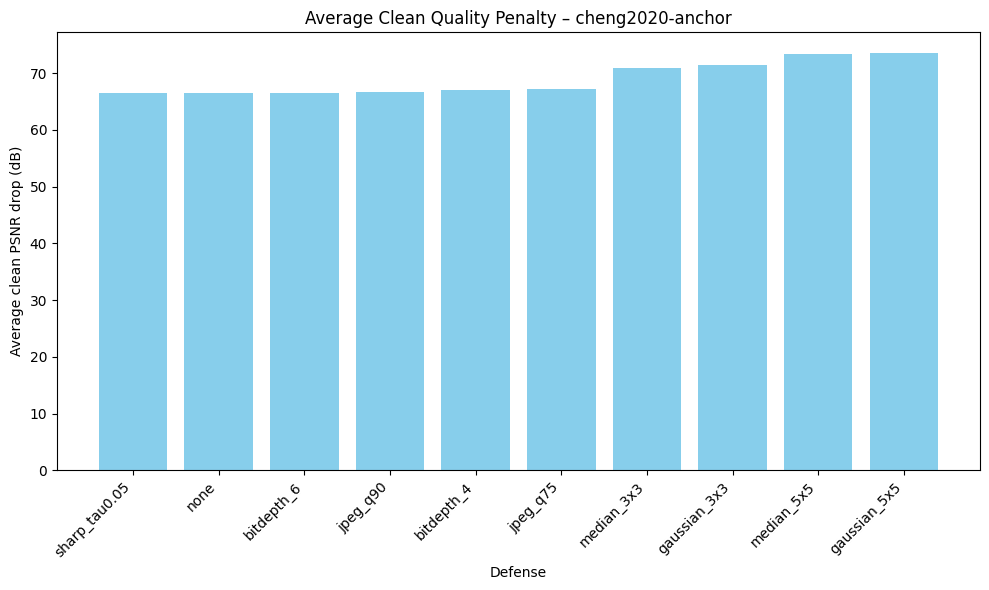

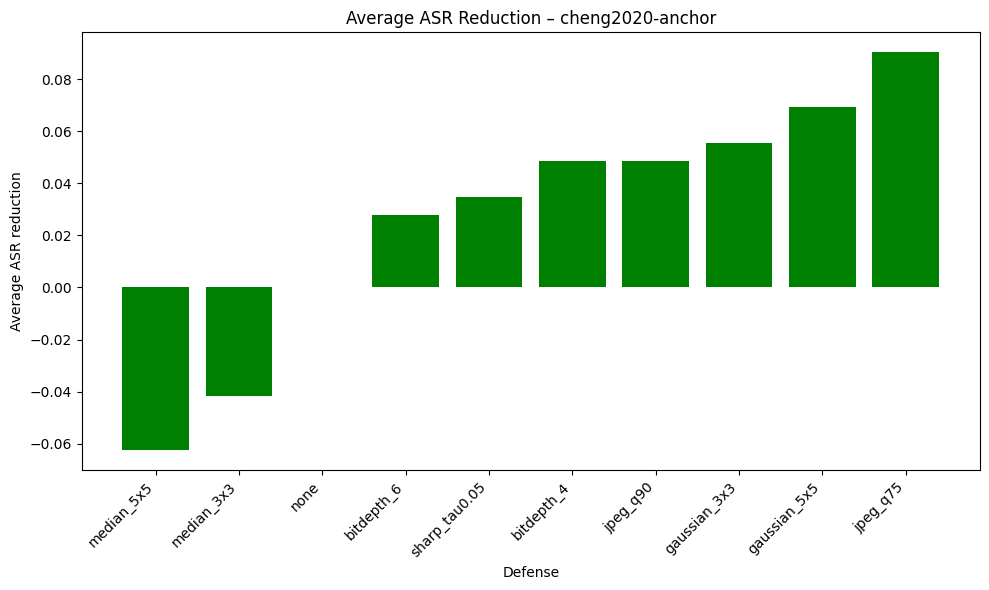

NameError: name 'attacks_to_save' is not defined

In [26]:
if __name__ == '__main__':
    # Model selection
    MODEL_NAME = 'cheng2020-anchor'   # change as needed
    # Load model
    if MODEL_NAME == 'cheng2020-attn':
        model = cheng2020_attn(quality=4, pretrained=True).eval().to(device)
    elif MODEL_NAME == 'cheng2020-anchor':
        model = cheng2020_anchor(quality=4, pretrained=True).eval().to(device)
    elif MODEL_NAME == 'mbt2018-mean':
        model = mbt2018_mean(quality=4, pretrained=True).eval().to(device)
    elif MODEL_NAME == 'bmshj2018_factorized':
        model = bmshj2018_factorized(quality=4, pretrained=True).eval().to(device)
    elif MODEL_NAME == 'bmshj2018_hyperprior':
        model = bmshj2018_hyperprior(quality=4, pretrained=True).eval().to(device)
    else:
        raise ValueError(f"Unknown model: {MODEL_NAME}")

    # Load Kodak images
    images = load_kodak(path='data/')   # adjust path
    if not images:
        raise RuntimeError("No images loaded. Check dataset path.")
    
    # Attack configurations
    eps_values = [4/255, 8/255]
    attack_configs = {
        'fgsm': {'attack_fn': fgsm_attack, 'params_template': {'eps': None}},  # eps will be filled later
        'pgd': {'attack_fn': pgd_attack, 'params_template': {'eps': None, 'steps': 20}},
        'apgd': {'attack_fn': apgd_attack, 'params_template': {'eps': None, 'steps': 20}},
    }

    results = []
    for def_name, def_fn in DEFENSES.items():
        for attack_name, config in attack_configs.items():
            for eps in eps_values:
                params = config['params_template'].copy()
                params['eps'] = eps
                print(f"\n--- Defense: {def_name} | Attack: {attack_name.upper()} | eps = {eps:.4f} ---")
                stats = evaluate_defense_before_attack(
                    model,
                    images,
                    def_fn,
                    config['attack_fn'],
                    params,
                    loss_fn=distortion_loss
                )
                stats['defense'] = def_name
                stats['attack'] = attack_name
                stats['eps'] = eps
                results.append(stats)

    df = pd.DataFrame(results)
    df.to_csv(f'defense_before_attack_{MODEL_NAME}.csv', index=False)
    print("\n=== Results ===")
    print(df)
    # --- Compute ASR reduction (relative to 'none' defense) ---
    df_with_reduction = df.copy()

# For each attack and eps, find the ASR for 'none' defense
    for (attack, eps), group in df.groupby(['attack', 'eps']):
            none_asr = group[group['defense'] == 'none']['asr'].values
        if len(none_asr) == 1:
            none_asr = none_asr[0]
        # Compute reduction for all defenses in this group
            mask = (df_with_reduction['attack'] == attack) & (df_with_reduction['eps'] == eps)
            df_with_reduction.loc[mask, 'asr_reduction'] = none_asr - df_with_reduction.loc[mask, 'asr']

# The 'none' defense will have reduction = 0 (since none_asr - none_asr = 0)
    print("\nASR reduction computed (asr_reduction column added).")

    # --- Average clean PSNR drop across all attacks and eps ---
    plt.figure(figsize=(10,6))
# Group by defense and compute mean clean_psnr_drop
    clean_penalty_avg = df.groupby('defense')['clean_psnr_drop'].mean().sort_values()
# Plot bar chart
    plt.bar(clean_penalty_avg.index, clean_penalty_avg.values, color='skyblue')
    plt.xlabel('Defense')
    plt.ylabel('Average clean PSNR drop (dB)')
    plt.title(f'Average Clean Quality Penalty - {MODEL_NAME}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'clean_penalty_avg_{MODEL_NAME}.png', dpi=150)
    plt.show()

# Plot ASR Reduction vs Clean PSNR Drop for each attack and eps
    for attack_name in attack_configs.keys():
        for eps in eps_values:
            df_sub = df_with_reduction[(df_with_reduction['attack'] == attack_name) & (df_with_reduction['eps'] == eps)]
            if len(df_sub) == 0:
                continue
            plt.figure(figsize=(10,6))
            plt.scatter(df_sub['clean_psnr_drop'], df_sub['asr_reduction'], s=100)
            for _, row in df_sub.iterrows():
                plt.annotate(row['defense'], (row['clean_psnr_drop'], row['asr_reduction']), fontsize=8)
            plt.xlabel('Clean PSNR drop due to defense (dB)')
            plt.ylabel('ASR reduction (fraction)')
            plt.title(f'ASR Reduction vs Clean Quality Penalty – {attack_name.upper()}, eps={eps:.4f}')
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f'asr_reduction_tradeoff_{MODEL_NAME}_{attack_name}_eps{int(eps*255)}.png', dpi=150)
            plt.close()

    for attack_name in attack_configs.keys():
        for eps in eps_values:
            df_sub = df[(df['attack'] == attack_name) & (df['eps'] == eps)]
            if len(df_sub) == 0:
                continue
            plt.figure(figsize=(10,6))
            plt.scatter(df_sub['clean_psnr_drop'], df_sub['attack_psnr_drop'], s=100)
            for _, row in df_sub.iterrows():
                plt.annotate(row['defense'], (row['clean_psnr_drop'], row['attack_psnr_drop']), fontsize=8)
            plt.xlabel('Clean PSNR drop due to defense (dB)')
            plt.ylabel('Attack PSNR drop after defense (dB)')
            plt.title(f'Defense trade-off: {attack_name.upper()}, eps={eps:.4f}')
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f'tradeoff_{MODEL_NAME}_{attack_name}_eps{int(eps*255)}.png', dpi=150)
            plt.close()

    # Plot ASR vs Clean PSNR Drop for each attack/eps
    for attack_name in attack_configs.keys():
        for eps in eps_values:
            df_sub = df[(df['attack'] == attack_name) & (df['eps'] == eps)]
            if len(df_sub) == 0:
                continue
            plt.figure(figsize=(10,6))
            plt.scatter(df_sub['clean_psnr_drop'], df_sub['asr'], s=100)
            for _, row in df_sub.iterrows():
                plt.annotate(row['defense'], (row['clean_psnr_drop'], row['asr']), fontsize=8)
            plt.xlabel('Clean PSNR drop due to defense (dB)')
            plt.ylabel('Attack Success Rate (ASR) after defense')
            plt.title(f'ASR vs Clean Quality Penalty – {attack_name.upper()}, eps={eps:.4f}')
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f'asr_tradeoff_{MODEL_NAME}_{attack_name}_eps{int(eps*255)}.png', dpi=150)
            plt.close()

    print("\nEvaluation complete. Results saved.")

    attacks_to_save = [
        ('fgsm', fgsm_attack, {'eps': 4/255}),
        ('fgsm', fgsm_attack, {'eps': 8/255}),# FGSM with eps=8/255
        ('pgd', pgd_attack, {'eps': 4/255, 'steps': 20}),
        ('pgd', pgd_attack, {'eps': 8/255, 'steps': 20}),# optional
        ('apgd', apgd_attack, {'eps': 4/255, 'steps': 20}),
        ('apgd', apgd_attack, {'eps': 8/255, 'steps': 20}),# optional
    ]

    output_root = 'all_images_defense_attack_cheng2020_anchor'
    os.makedirs(output_root, exist_ok=True)

    # Loop over all Kodak images (not just the first three)
    for idx, img_tensor in enumerate(images):
        img_tensor = img_tensor.to(device)

        img_name = f"kodim{idx+1:02d}"               # e.g., kodim01, kodim02, ...
        img_dir = os.path.join(output_root, img_name)
        os.makedirs(img_dir, exist_ok=True)

        orig_path = os.path.join(img_dir, f"{img_name}_original.png")
        transforms.ToPILImage()(img_tensor.squeeze(0).cpu()).save(orig_path)

        for def_name, def_fn in DEFENSES.items():
            if def_name == 'none':
                continue

            img_def = def_fn(img_tensor)

            def_path = os.path.join(img_dir, f"{img_name}_{def_name}.png")
            transforms.ToPILImage()(img_def.squeeze(0).cpu()).save(def_path)

            for attack_name, attack_fn, attack_params in attacks_to_save:
                x_adv, _ = attack_fn(model, img_def, **attack_params, loss_fn=distortion_loss)

                adv_path = os.path.join(img_dir, f"{img_name}_{def_name}_{attack_name}.png")
                transforms.ToPILImage()(x_adv.squeeze(0).cpu()).save(adv_path)

                with torch.no_grad():
                    out = model(x_adv)
                    x_hat = out['x_hat']
                recon_path = os.path.join(img_dir, f"{img_name}_{def_name}_{attack_name}_recon.png")
                transforms.ToPILImage()(x_hat.squeeze(0).cpu()).save(recon_path)

    print(f"\nAll images saved in '{output_root}/'")

    eps_values = [4/255, 8/255]
    attack_configs = {
        'fgsm': {'attack_fn': fgsm_attack, 'params_template': {'eps': None}},
        'pgd': {'attack_fn': pgd_attack, 'params_template': {'eps': None, 'steps': 20}},
        'apgd': {'attack_fn': apgd_attack, 'params_template': {'eps': None, 'steps': 20}},
    }

    # ---------------------------
    # 4. Evaluate all combinations (defense, attack, eps)
    # ---------------------------
    results = []
    for def_name, def_fn in DEFENSES.items():
        for attack_name, config in attack_configs.items():
            for eps in eps_values:
                params = config['params_template'].copy()
                params['eps'] = eps
                print(f"\n--- Defense: {def_name} | Attack: {attack_name.upper()} | eps = {eps:.4f} ---")
                stats = evaluate_defense_before_attack(
                    model,
                    images,
                    def_fn,
                    config['attack_fn'],
                    params,
                    loss_fn=distortion_loss,
                    asr_threshold=1.0      # PSNR drop > 1 dB counts as success
                )
                stats['defense'] = def_name
                stats['attack'] = attack_name
                stats['eps'] = eps
                results.append(stats)

    # Convert to DataFrame and save
    df = pd.DataFrame(results)
    df.to_csv(f'defense_before_attack_{MODEL_NAME}.csv', index=False)
    print("\n=== Raw Results ===")
    print(df)

    # ---------------------------
    # 5. Compute ASR reduction relative to 'none' defense
    # ---------------------------
    df_with_reduction = df.copy()
    for (attack, eps), group in df.groupby(['attack', 'eps']):
        none_asr = group[group['defense'] == 'none']['asr'].values
        if len(none_asr) == 1:
            none_asr = none_asr[0]
            mask = (df_with_reduction['attack'] == attack) & (df_with_reduction['eps'] == eps)
            df_with_reduction.loc[mask, 'asr_reduction'] = none_asr - df_with_reduction.loc[mask, 'asr']

    # Save the augmented DataFrame
    df_with_reduction.to_csv(f'defense_before_attack_{MODEL_NAME}_with_reduction.csv', index=False)

    # ---------------------------
    # 6. Plotting
    # ---------------------------

    # 6.1 Trade‑off: clean PSNR drop vs attack PSNR drop
    for attack_name in attack_configs.keys():
        for eps in eps_values:
            df_sub = df[(df['attack'] == attack_name) & (df['eps'] == eps)]
            if len(df_sub) == 0:
                continue
            plt.figure(figsize=(10,6))
            plt.scatter(df_sub['clean_psnr_drop'], df_sub['attack_psnr_drop'], s=100)
            for _, row in df_sub.iterrows():
                plt.annotate(row['defense'], (row['clean_psnr_drop'], row['attack_psnr_drop']), fontsize=8)
            plt.xlabel('Clean PSNR drop due to defense (dB)')
            plt.ylabel('Attack PSNR drop after defense (dB)')
            plt.title(f'Defense trade-off: {attack_name.upper()}, eps={eps:.4f}')
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f'tradeoff_{MODEL_NAME}_{attack_name}_eps{int(eps*255)}.png', dpi=150)
            plt.close()

    # 6.2 ASR reduction vs clean PSNR drop
    for attack_name in attack_configs.keys():
        for eps in eps_values:
            df_sub = df_with_reduction[(df_with_reduction['attack'] == attack_name) & (df_with_reduction['eps'] == eps)]
            if len(df_sub) == 0:
                continue
            plt.figure(figsize=(10,6))
            plt.scatter(df_sub['clean_psnr_drop'], df_sub['asr_reduction'], s=100)
            for _, row in df_sub.iterrows():
                plt.annotate(row['defense'], (row['clean_psnr_drop'], row['asr_reduction']), fontsize=8)
            plt.xlabel('Clean PSNR drop due to defense (dB)')
            plt.ylabel('ASR reduction (fraction)')
            plt.title(f'ASR reduction vs clean penalty – {attack_name.upper()}, eps={eps:.4f}')
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f'asr_reduction_{MODEL_NAME}_{attack_name}_eps{int(eps*255)}.png', dpi=150)
            plt.close()

    # 6.3 Average clean PSNR drop bar chart (across all attacks/eps)
    avg_clean_penalty = df.groupby('defense')['clean_psnr_drop'].mean().sort_values()
    plt.figure(figsize=(10,6))
    plt.bar(avg_clean_penalty.index, avg_clean_penalty.values, color='skyblue')
    plt.xlabel('Defense')
    plt.ylabel('Average clean PSNR drop (dB)')
    plt.title(f'Average Clean Quality Penalty – {MODEL_NAME}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'avg_clean_penalty_{MODEL_NAME}.png', dpi=150)
    plt.show()

    # 6.4 Average ASR reduction bar chart (across all attacks/eps)
    # Note: for 'none' defense, reduction is zero by construction
    avg_asr_reduction = df_with_reduction.groupby('defense')['asr_reduction'].mean().sort_values()
    plt.figure(figsize=(10,6))
    plt.bar(avg_asr_reduction.index, avg_asr_reduction.values, color='green')
    plt.xlabel('Defense')
    plt.ylabel('Average ASR reduction')
    plt.title(f'Average ASR Reduction – {MODEL_NAME}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'avg_asr_reduction_{MODEL_NAME}.png', dpi=150)
    plt.show()

    # ---------------------------
    # 7. (Optional) Save example images for all defenses and attacks
    #    This may create many files; you can skip or adjust.
    # ---------------------------
    output_root = 'all_images_defense_attack_cheng2020_anchor'
    os.makedirs(output_root, exist_ok=True)

    # Loop over all Kodak images (not just the first three)
    for idx, img_tensor in enumerate(images):
        img_tensor = img_tensor.to(device)

        img_name = f"kodim{idx+1:02d}"               # e.g., kodim01, kodim02, ...
        img_dir = os.path.join(output_root, img_name)
        os.makedirs(img_dir, exist_ok=True)

        orig_path = os.path.join(img_dir, f"{img_name}_original.png")
        transforms.ToPILImage()(img_tensor.squeeze(0).cpu()).save(orig_path)

        for def_name, def_fn in DEFENSES.items():
            if def_name == 'none':
                continue

            img_def = def_fn(img_tensor)

            def_path = os.path.join(img_dir, f"{img_name}_{def_name}.png")
            transforms.ToPILImage()(img_def.squeeze(0).cpu()).save(def_path)

            for attack_name, attack_fn, attack_params in attacks_to_save:
                x_adv, _ = attack_fn(model, img_def, **attack_params, loss_fn=distortion_loss)

                adv_path = os.path.join(img_dir, f"{img_name}_{def_name}_{attack_name}.png")
                transforms.ToPILImage()(x_adv.squeeze(0).cpu()).save(adv_path)

                with torch.no_grad():
                    out = model(x_adv)
                    x_hat = out['x_hat']
                recon_path = os.path.join(img_dir, f"{img_name}_{def_name}_{attack_name}_recon.png")
                transforms.ToPILImage()(x_hat.squeeze(0).cpu()).save(recon_path)

    print(f"\nAll images saved in '{output_root}/'")


In [30]:
    attacks_to_save = [
        ('fgsm', fgsm_attack, {'eps': 4/255}),
        ('fgsm', fgsm_attack, {'eps': 8/255}),# FGSM with eps=8/255
        ('pgd', pgd_attack, {'eps': 4/255, 'steps': 20}),
        ('pgd', pgd_attack, {'eps': 8/255, 'steps': 20}),# optional
        ('apgd', apgd_attack, {'eps': 4/255, 'steps': 20}),
        ('apgd', apgd_attack, {'eps': 8/255, 'steps': 20}),# optional
    ]


    for idx, img_tensor in enumerate(images):
        img_tensor = img_tensor.to(device)

        img_name = f"kodim{idx+1:02d}"               # e.g., kodim01, kodim02, ...
        img_dir = os.path.join(output_root, img_name)
        os.makedirs(img_dir, exist_ok=True)

        orig_path = os.path.join(img_dir, f"{img_name}_original.png")
        transforms.ToPILImage()(img_tensor.squeeze(0).cpu()).save(orig_path)

        for def_name, def_fn in DEFENSES.items():
            if def_name == 'none':
                continue

            img_def = def_fn(img_tensor)

            def_path = os.path.join(img_dir, f"{img_name}_{def_name}.png")
            transforms.ToPILImage()(img_def.squeeze(0).cpu()).save(def_path)

            for attack_name, attack_fn, attack_params in attacks_to_save:
                x_adv, _ = attack_fn(model, img_def, **attack_params, loss_fn=distortion_loss)

                adv_path = os.path.join(img_dir, f"{img_name}_{def_name}_{attack_name}.png")
                transforms.ToPILImage()(x_adv.squeeze(0).cpu()).save(adv_path)

                with torch.no_grad():
                    out = model(x_adv)
                    x_hat = out['x_hat']
                recon_path = os.path.join(img_dir, f"{img_name}_{def_name}_{attack_name}_recon.png")
                transforms.ToPILImage()(x_hat.squeeze(0).cpu()).save(recon_path)

    print(f"\nAll images saved in '{output_root}/'")

/opt/anaconda3/lib/python3.12/site-packages/torchvision/transforms/functional.py:282: RuntimeWarning: invalid value encountered in cast
  npimg = (npimg * 255).astype(np.uint8)



All images saved in 'all_images_defense_attack_cheng2020_anchor/'
